<a href="https://colab.research.google.com/github/KARTHIKAKRISHNA123/AIML_Learnings/blob/main/CNN_mnist_and_cifar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, models



In [41]:
#Load the Dataset

from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()



In [42]:
import matplotlib.pyplot as plt
import numpy as np

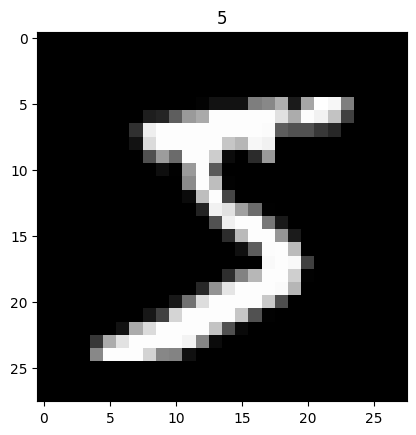

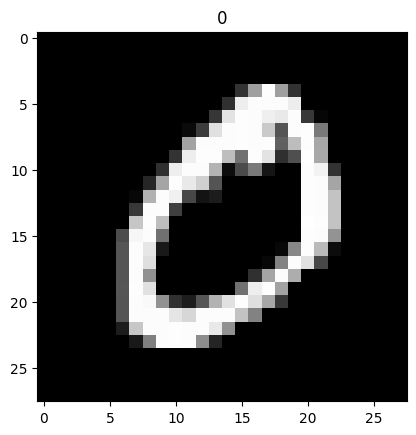

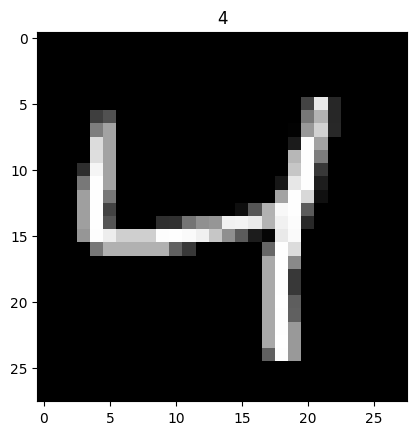

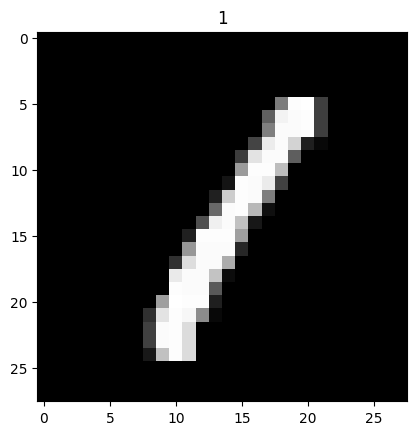

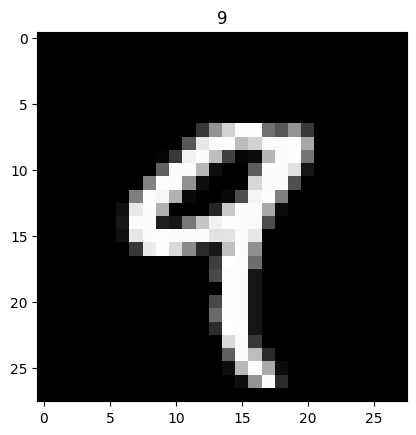

In [43]:
#first 5 images
for i in range(5):
  plt.imshow(x_train[i], cmap="gray")
  plt.title(y_train[i])
  plt.show()

In [44]:
#check the shape of my data
print("shape", x_train.shape)

shape (60000, 28, 28)


In [45]:
print("one image shape", x_train[1].shape)

one image shape (28, 28)


In [46]:
print("Pixel Range of the dataset", x_train.min(), x_train.max())

Pixel Range of the dataset 0 255


In [47]:
print(x_train[1])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253
  159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252
  252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239
  233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202
   84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 163 252 252 252 25

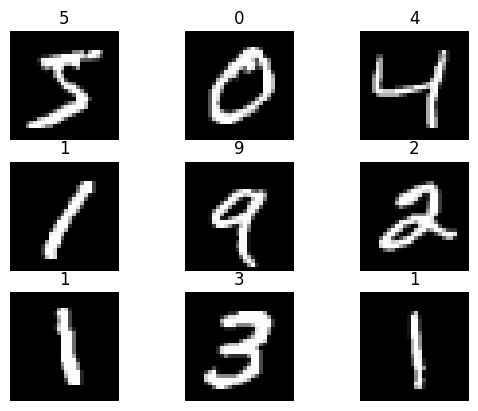

In [48]:
for i in range(9):
  plt.subplot(3, 3, i + 1)
  plt.imshow(x_train[i], cmap="gray")
  plt.title(y_train[i])
  plt.axis("off")
plt.show()

In [49]:
unique, count = np.unique(y_train, return_counts=True)
print(dict(zip(unique, count)))

{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


In [50]:
unique_value = np.unique(y_train)
unique_value

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [51]:
#untill now EDA
#then preprocessing

x_train = x_train / 255.0
x_test = x_test / 255.0

In [52]:
#reshape of the images
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [53]:
#different sizes convolution will not work
#build the Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)), # Recommended way to specify input shape
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [54]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# size = w - f + 2p + 1

model.compile(optimizer="adam", loss= "sparse_categorical_crossentropy", metrics=["accuracy"])



In [56]:
model.fit(x_train, y_train, epochs=10, verbose=2)

Epoch 1/10
1875/1875 - 62s - 33ms/step - accuracy: 0.9568 - loss: 0.1414
Epoch 2/10
1875/1875 - 76s - 40ms/step - accuracy: 0.9851 - loss: 0.0477
Epoch 3/10
1875/1875 - 53s - 28ms/step - accuracy: 0.9895 - loss: 0.0335
Epoch 4/10
1875/1875 - 53s - 28ms/step - accuracy: 0.9923 - loss: 0.0248
Epoch 5/10
1875/1875 - 58s - 31ms/step - accuracy: 0.9937 - loss: 0.0190
Epoch 6/10
1875/1875 - 55s - 30ms/step - accuracy: 0.9951 - loss: 0.0146
Epoch 7/10
1875/1875 - 60s - 32ms/step - accuracy: 0.9963 - loss: 0.0108
Epoch 8/10
1875/1875 - 85s - 45ms/step - accuracy: 0.9966 - loss: 0.0103
Epoch 9/10
1875/1875 - 58s - 31ms/step - accuracy: 0.9972 - loss: 0.0084
Epoch 10/10
1875/1875 - 57s - 31ms/step - accuracy: 0.9975 - loss: 0.0068


In [59]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9913 - loss: 0.0333
Test Accuracy:  0.9912999868392944


In [57]:
#To save the model
model.save("mnist.h5") #extension to save a model in tensorflow hdfs(hadoop distributed file system)

In [57]:
model.save_weights("model.weights.h5")

In [66]:
#model.load_weights("model.weights.h5")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'model.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [68]:
model = tf.keras.models.load_model("mnist.h5")

In [69]:
img_path = "/content/59026a58d480b3297899be25481d80fa.jpg"

In [70]:
from tensorflow.keras.preprocessing import image


img = image.load_img(img_path, target_size=(28, 28), color_mode="grayscale")
img_array = image.img_to_array(img)

In [71]:
img_array

array([[[  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.]],

       [[  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.]],

       [[  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
    

In [72]:
img_array = img_array / 255.0

In [73]:
img_array = np.expand_dims(img_array, axis=0)

In [74]:
#prediction
prediction = model.predict(img_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


In [77]:
prediction_class = np.argmax(prediction)

In [79]:
prediction_class


np.int64(1)

In [80]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [81]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [82]:
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

In [83]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 58ms/step - accuracy: 0.4677 - loss: 1.4629 - val_accuracy: 0.5425 - val_loss: 1.2550
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.6159 - loss: 1.0888 - val_accuracy: 0.6405 - val_loss: 1.0250
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 54ms/step - accuracy: 0.6746 - loss: 0.9287 - val_accuracy: 0.6807 - val_loss: 0.9158
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.7118 - loss: 0.8170 - val_accuracy: 0.6981 - val_loss: 0.8627
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.7454 - loss: 0.7241 - val_accuracy: 0.7109 - val_loss: 0.8579
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 55ms/step - accuracy: 0.7729 - loss: 0.6466 - val_accuracy: 0.6987 - val_loss: 0.8915
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 55ms/step - accuracy: 0.7960 - loss: 0.5779 - val_accuracy: 0.7132 - val_loss: 0.8812
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 54ms/step - accuracy: 0.8191

In [86]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/59026a58d480b3297899be25481d80fa.jpg"

img = image.load_img(img_path, target_size=(32, 32))  # RGB by default
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

print("Predicted:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted: airplane
